# 03 — Factor & Sector Decomposition



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 160)

In [21]:
df = pd.read_csv(
    "../data/processed/master_daily_2003_2024.csv",
    parse_dates=["date"],
    index_col="date",
).sort_index()

df.shape, df.index.min(), df.index.max()

((5356, 57),
 Timestamp('2003-09-22 00:00:00'),
 Timestamp('2024-12-31 00:00:00'))

In [22]:
df["P_60_40"] = 0.6 * df["SPY_RET"] + 0.4 * df["AGG_RET"]
y = df["P_60_40"].dropna()
y.name

/var/folders/y1/t79wmh0x3zvfvmjwgtpyh9h40000gn/T/ipykernel_60380/832483870.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["P_60_40"] = 0.6 * df["SPY_RET"] + 0.4 * df["AGG_RET"]


'P_60_40'

In [23]:
sector_map = {
    "Tech": ["Softw", "Chips"],
    "Financials": ["Banks", "Insur", "Fin"],
    "Energy": ["Oil", "Coal", "Mines"],
    "Industrials": ["Mach", "Trans", "Aero"],
    "Consumer": ["Food", "Rtail", "Meals"],
    "Healthcare": ["Hlth", "MedEq", "Drugs"],
}

missing = {k: [c for c in cols if c not in df.columns] for k, cols in sector_map.items()}
missing

{'Tech': [],
 'Financials': [],
 'Energy': [],
 'Industrials': [],
 'Consumer': [],
 'Healthcare': []}

In [24]:
[c for c in df.columns if "Soft" in c or "Chip" in c or "Bank" in c][:50]

['Softw', 'Chips', 'Banks']

In [ ]:
df.columns[-60:] 

Index(['SPY_RET', 'AGG_RET', 'mktrf', 'smb', 'hml', 'rf', 'umd', 'Agric', 'Food', 'Soda', 'Beer', 'Smoke', 'Toys', 'Fun', 'Books', 'Hshld', 'Clths', 'Hlth',
       'MedEq', 'Drugs', 'Chems', 'Rubbr', 'Txtls', 'BldMt', 'Cnstr', 'Steel', 'FabPr', 'Mach', 'ElcEq', 'Autos', 'Aero', 'Ships', 'Guns', 'Gold', 'Mines',
       'Coal', 'Oil', 'Util', 'Telcm', 'PerSv', 'BusSv', 'Hardw', 'Softw', 'Chips', 'LabEq', 'Paper', 'Boxes', 'Trans', 'Whlsl', 'Rtail', 'Meals', 'Banks',
       'Insur', 'RlEst', 'Fin', 'Other', 'VIX', 'P_60_40'],
      dtype='object')

In [26]:
sectors = pd.DataFrame(
    {k: df[cols].mean(axis=1) for k, cols in sector_map.items()},
    index=df.index
)

sectors.head()

,Tech,Financials,Energy,Industrials,Consumer,Healthcare
date,,,,,,
2003-09-22,-0.00980,-0.007333,-0.002333,-0.007967,-0.005000,-0.001200
2003-09-23,0.01575,0.006067,0.004033,0.005267,0.007000,0.011000
2003-09-24,-0.02380,-0.009733,0.005067,-0.017167,-0.005833,-0.015200
2003-09-25,-0.02480,-0.011900,-0.018233,-0.014300,-0.011667,-0.020033
2003-09-26,-0.02665,-0.009300,-0.020533,-0.012967,-0.013000,-0.021533


In [27]:
factor_cols = ["mktrf", "smb", "hml", "umd"]
X_f = df[factor_cols].copy()

X_f.describe().T[["mean","std"]]

,mean,std
mktrf,0.000419,0.011984
smb,-0.000001,0.006195
hml,-0.000011,0.007804
umd,0.000074,0.010331


In [28]:
Z = pd.concat([y, X_f, sectors], axis=1).dropna()
Z.shape

(5351, 11)

In [29]:
Y = Z["P_60_40"]
X1 = sm.add_constant(Z[factor_cols])

m1 = sm.OLS(Y, X1).fit()
m1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                P_60_40   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                 2.388e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:59:16   Log-Likelihood:                 26702.
No. Observations:                5351   AIC:                        -5.339e+04
Df Residuals:                    5346   BIC:                        -5.336e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.135e-05   2.25e-05      3.610      0.000    3.72e-05       0.000
mktrf          0.5889      0.002    296.539      0.000       0.585       0.593
smb           -0.0842      0.004    -22.556      0.000      -0.092      -0.077
hml           -0.0267      0.003     -8.337      0.000      -0.033      -0.020
umd           -0.0101      0.002     -4.114      0.000      -0.015      -0.005
==============================================================================
Omnibus:                     2035.791   Durbin-Watson:                   2.307
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1058416.795
Skew:                          -0.326   Prob(JB):                         0.00
Kurtosis:                      71.896   Cond. No.                         170.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
X2 = sm.add_constant(pd.concat([Z[factor_cols], Z[sectors.columns]], axis=1))

m2 = sm.OLS(Y, X2).fit()
m2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                P_60_40   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     9693.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:59:16   Log-Likelihood:                 26742.
No. Observations:                5351   AIC:                        -5.346e+04
Df Residuals:                    5340   BIC:                        -5.339e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        7.204e-05   2.25e-05      3.197      0.001    2.79e-05       0.000
mktrf           0.5487      0.009     60.278      0.000       0.531       0.567
smb            -0.1147      0.007    -16.185      0.000      -0.129      -0.101
hml            -0.0420      0.006     -7.588      0.000      -0.053      -0.031
umd            -0.0045      0.003     -1.712      0.087      -0.010       0.001
Tech           -0.0183      0.005     -3.699      0.000      -0.028      -0.009
Financials      0.0071      0.007      0.960      0.337      -0.007       0.021
Energy          0.0028      0.002      1.757      0.079      -0.000       0.006
Industrials     0.0154      0.005      3.096      0.002       0.006       0.025
Consumer        0.0265      0.005      5.228      0.000       0.017       0.036
Healthcare      0.0156      0.004      3.987      0.000       0.008       0.023
==============================================================================
Omnibus:                     1930.572   Durbin-Watson:                   2.317
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           888376.827
Skew:                          -0.171   Prob(JB):                         0.00
Kurtosis:                      66.122   Cond. No.                         569.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
betas = pd.DataFrame({
    "Factors only": m1.params,
    "Factors+Sectors": m2.params
}).drop(index="const")

betas

,Factors only,Factors+Sectors
Consumer,NaN,0.026512
Energy,NaN,0.002817
Financials,NaN,0.007061
Healthcare,NaN,0.015642
Industrials,NaN,0.015412
Tech,NaN,-0.018296
hml,-0.026660,-0.041956
mktrf,0.588863,0.548660
smb,-0.084203,-0.114699
umd,-0.010106,-0.004455


In [32]:
def variance_decomp(model, X, Y):
    yhat = model.predict(X)
    resid = Y - yhat
    return {
        "Var(Y)": float(Y.var(ddof=0)),
        "Var(Explained)": float(yhat.var(ddof=0)),
        "Var(Residual)": float(resid.var(ddof=0)),
        "Explained %": float(yhat.var(ddof=0) / Y.var(ddof=0)),
    }

vd1 = variance_decomp(m1, X1, Y)
vd2 = variance_decomp(m2, X2, Y)

pd.DataFrame([vd1, vd2], index=["Factors only", "Factors+Sectors"])

,Var(Y),Var(Explained),Var(Residual),Explained %
Factors only,0.000051,0.000048,0.000003,0.947009
Factors+Sectors,0.000051,0.000048,0.000003,0.947783


In [ ]:
def approx_driver_contrib(X_no_const: pd.DataFrame, betas: pd.Series, Y: pd.Series):
    contrib = {}
    for col in X_no_const.columns:
        contrib[col] = float((betas[col] * X_no_const[col]).var(ddof=0))
    total = float(Y.var(ddof=0))
    out = pd.Series(contrib).sort_values(ascending=False)
    return pd.DataFrame({
        "Var contrib": out,
        "% of total var": out / total
    })

X2_no = pd.concat([Z[factor_cols], Z[sectors.columns]], axis=1)
beta2 = m2.params.drop("const")

contrib2 = approx_driver_contrib(X2_no, beta2, Y)
contrib2.head(15)

,Var contrib,% of total var
mktrf,4.322231e-05,0.844822
smb,5.041086e-07,0.009853
hml,1.072975e-07,0.002097
Consumer,1.068333e-07,0.002088
Tech,6.786886e-08,0.001327
Industrials,5.267518e-08,0.001030
Healthcare,4.436887e-08,0.000867
Financials,8.457934e-09,0.000165
Energy,4.210318e-09,0.000082
umd,2.118522e-09,0.000041


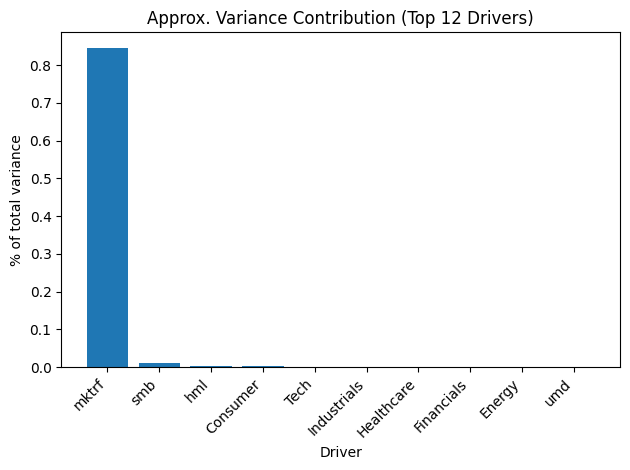

In [34]:
top = contrib2.head(12)["% of total var"]

plt.figure()
plt.bar(top.index, top.values)
plt.title("Approx. Variance Contribution (Top 12 Drivers)")
plt.xlabel("Driver")
plt.ylabel("% of total variance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

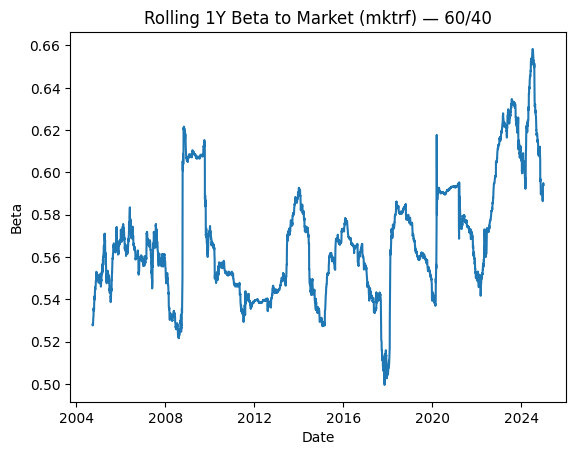

In [ ]:
window = 252

def rolling_beta(Y, X, window=252):
    betas = []
    idx = []
    for i in range(window, len(Y)+1):
        y_ = Y.iloc[i-window:i]
        x_ = X.iloc[i-window:i]
        X_ = sm.add_constant(x_)
        res = sm.OLS(y_, X_).fit()
        betas.append(res.params.iloc[1])
        idx.append(Y.index[i-1])
    return pd.Series(betas, index=idx)

rb_mkt = rolling_beta(Z["P_60_40"], Z["mktrf"], window=window)

plt.figure()
plt.plot(rb_mkt.index, rb_mkt.values)
plt.title("Rolling 1Y Beta to Market (mktrf) — 60/40")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.show()

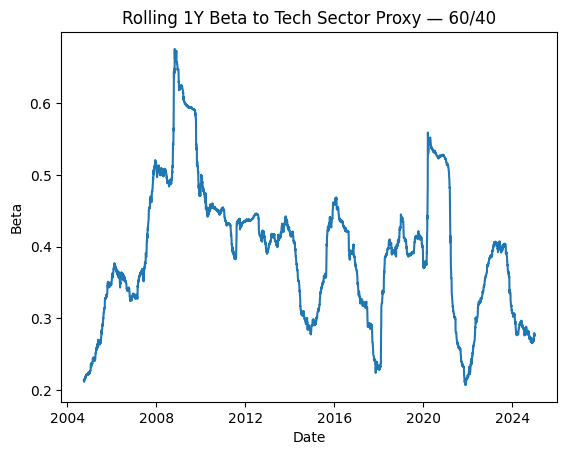

In [36]:
rb_tech = rolling_beta(Z["P_60_40"], Z["Tech"], window=window)

plt.figure()
plt.plot(rb_tech.index, rb_tech.values)
plt.title("Rolling 1Y Beta to Tech Sector Proxy — 60/40")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.show()